In [4]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# ⚠️ 注意：这里读取的应该是你 Left Join 了 OB 和 HFT 并填好缺失值的那个终极宽表
df = pd.read_parquet("../data/ultimate_data.parquet")
df = df.sort_values(['slug', 'timestamp']).reset_index(drop=True)

# ==========================================
# 1. Data Cleaning
# ==========================================
df = df.dropna(subset=['strike_price']).copy()
MIN_REQUIRED_SECONDS = 850  # bottom line of how long available chainlink data
MAX_FLATLINE_SECONDS = 120  # 2 minutes no update of chainlink

valid_slugs = []
for slug, group in df.groupby('slug'):
    if len(group) < MIN_REQUIRED_SECONDS:
        continue

    max_consecutive_flat = (group['chainlink_price'].diff() != 0).cumsum().value_counts().max()
    if max_consecutive_flat > MAX_FLATLINE_SECONDS:
        continue
        
    valid_slugs.append(slug)

df = df[df['slug'].isin(valid_slugs)].copy()

# # ==========================================
# # 2. Macro Regime Features
# # ==========================================
# df['temp_btc_return_1s'] = df.groupby('slug')['chainlink_price'].pct_change()

# contract_summary = df.groupby('slug').agg(
#     first_price=('chainlink_price', 'first'),
#     last_price=('chainlink_price', 'last'),
#     contract_rv=('temp_btc_return_1s', 'std') 
# ).reset_index()

# contract_summary['resolve_ts'] = contract_summary['slug'].apply(lambda x: int(x.split('-')[-1]))
# contract_summary = contract_summary.sort_values('resolve_ts').reset_index(drop=True)

# contract_summary['contract_return'] = (contract_summary['last_price'] - contract_summary['first_price']) / contract_summary['first_price']
# contract_summary['prev_contract_return'] = contract_summary['contract_return'].shift(1)
# contract_summary['prev_contract_rv'] = contract_summary['contract_rv'].shift(1)

# features_to_merge = contract_summary[['slug', 'prev_contract_return', 'prev_contract_rv']]
# df = df.merge(features_to_merge, on='slug', how='left')
# df['prev_contract_return'] = df['prev_contract_return'].fillna(0)
# df['prev_contract_rv'] = df['prev_contract_rv'].fillna(0)

# df = df.drop(columns=['temp_btc_return_1s'])

# ==========================================
# 2. Macro Regime Features (零穿越、全局滚动版)
# ==========================================
print("🌐 正在构建全局宏观环境特征 (零穿越)...")

# 1. 抽取一条纯净的大盘 (Chainlink) 时间线
# 去掉 slug，只看时间戳和对应的标的价格
macro_df = df[['timestamp', 'chainlink_price']].sort_values('timestamp').drop_duplicates(subset=['timestamp'])

# 为了方便做时间窗口滚动，把 timestamp 临时设为 DateTimeIndex
macro_df['datetime'] = pd.to_datetime(macro_df['timestamp'], unit='s', utc=True)
macro_df.set_index('datetime', inplace=True)

# 2. 计算全局滚动特征 (严格基于当前时间点往回看)
# 比如：过去 1 小时 (1H) 的大盘收益率
macro_df['macro_return_1h'] = macro_df['chainlink_price'] / macro_df['chainlink_price'].shift(freq='1H') - 1.0

# 计算过去 1 小时的大盘年化波动率 (RV)
# 先算 1 秒级的收益率，然后做 1 小时窗口的滚动标准差
SECONDS_IN_YEAR = 31536000
macro_df['temp_1s_ret'] = macro_df['chainlink_price'].pct_change()
macro_df['macro_rv_1h'] = macro_df['temp_1s_ret'].rolling('1H').std() * np.sqrt(SECONDS_IN_YEAR)

# 3. 整理宏观表，准备拼回主表
macro_df = macro_df.reset_index()[['timestamp', 'macro_return_1h', 'macro_rv_1h']]
# 丢掉最开始算不出 1H 数据的时段
macro_df = macro_df.dropna() 

# 4. ⚡ 神级拼接：用 merge_asof 把宏观状态严丝合缝地贴回截面
# direction='backward' 保证了：在 09:05:00，只能拿到 <= 09:05:00 的宏观数据，绝对看不到未来！
df = df.sort_values('timestamp') # merge_asof 必须确保左表也是按时间排序的
df = pd.merge_asof(
    df, 
    macro_df, 
    on='timestamp', 
    direction='backward'
)

# 填补可能出现的极少数残缺
df['macro_return_1h'] = df['macro_return_1h'].fillna(0)
df['macro_rv_1h'] = df['macro_rv_1h'].fillna(df['macro_rv_1h'].median()) # RV 用中位数填补比较稳

# ==========================================
# 3. Cross-Sectional Features & Greeks
# ==========================================
# TTM
df['resolve_ts'] = df['slug'].apply(lambda x: int(x.split('-')[-1]))
df['resolve_time'] = pd.to_datetime(df['resolve_ts'] + 900, unit='s', utc=True)
df['time_to_expiry'] = (df['resolve_time'] - df['timestamp']).dt.total_seconds()
df.drop(columns=['resolve_ts', 'resolve_time'], inplace=True)

# Moneyness
df['moneyness'] = df['chainlink_price'] - df['strike_price']

# N(d2) and Delta
SECONDS_IN_YEAR = 31536000

df['btc_return_1s'] = df.groupby('slug')['chainlink_price'].pct_change()
df['ewma_rv_1s'] = df.groupby('slug')['btc_return_1s'].ewm(span=120, min_periods=2).std().reset_index(level=0, drop=True)

# ⚠️ 友情提示：确保你之前的表里有 Up_trade_close 这个列，或者用 Up_BUY_close_price 替代
if 'Up_trade_close' in df.columns:
    df['Up_price_momentum_15s'] = df.groupby('slug')['Up_trade_close'].pct_change(periods=15)

S = df['chainlink_price']
K = df['strike_price']
T_years = (df['time_to_expiry'].clip(lower=0) + 1e-9) / SECONDS_IN_YEAR 
prev_rv_annualized = df['prev_contract_rv'] * np.sqrt(SECONDS_IN_YEAR)
prev_rv_annualized = prev_rv_annualized.replace(0, 0.10) 
current_rv_annualized = df['ewma_rv_1s'] * np.sqrt(SECONDS_IN_YEAR)
df['sigma_annualized'] = current_rv_annualized.fillna(prev_rv_annualized)
df['sigma_annualized'] = df['sigma_annualized'].replace(0, np.nan).fillna(prev_rv_annualized)
df['sigma_annualized'] = df['sigma_annualized'].clip(lower=0.05) 
sigma = df['sigma_annualized']
d2 = (np.log(S / K) - (0.5 * sigma**2) * T_years) / (sigma * np.sqrt(T_years))

df['bsm_theoretical_price'] = norm.cdf(d2)
df['bsm_delta'] = norm.pdf(d2) / (sigma * S * np.sqrt(T_years))

# ==========================================
# 4. Microstructure Features (5s 预测极简核心版)
# ==========================================

# ---------------------------------------------------------
# A. 静态盘口特征 (Maker 挂单墙)
# ---------------------------------------------------------
# 1. 订单簿失衡 (OBI) - 挡在前面的墙哪边厚？
df['Up_OBI'] = (df['Up_book_bid_vol_5'] - df['Up_book_ask_vol_5']) / \
               (df['Up_book_bid_vol_5'] + df['Up_book_ask_vol_5']).replace(0, np.nan)
df['Up_OBI'] = df['Up_OBI'].fillna(0)

# 2. 盘口流动性摩擦 (Spread)
df['Up_spread'] = df['Up_book_ask1_price'] - df['Up_book_bid1_price']
df['Up_Mid_Price'] = (df['Up_book_bid1_price'] + df['Up_book_ask1_price']) / 2
df['Down_Mid_Price'] = 1.0 - df['Up_Mid_Price']

# 3. 微观公允价 (Micro-Price) - 吸收了挂单量权重的真实价格
df['Up_micro_price'] = (df['Up_book_bid1_price'] * df['Up_book_ask1_size'] + 
                        df['Up_book_ask1_price'] * df['Up_book_bid1_size']) / \
                       (df['Up_book_bid1_size'] + df['Up_book_ask1_size']).replace(0, np.nan)
if 'Up_trade_close' in df.columns:
    df['Up_micro_price'] = df['Up_micro_price'].fillna(df['Up_trade_close']) 

# ---------------------------------------------------------
# B. 动态交易特征 (Taker 开火猛烈程度)
# ---------------------------------------------------------
# 聚合多空双向的数据 (Size = 币量, Count = 笔数, Notional = 金额)
bull_size = df.get('Up_BUY_trade_size', 0) + df.get('Down_SELL_trade_size', 0)
bear_size = df.get('Up_SELL_trade_size', 0) + df.get('Down_BUY_trade_size', 0)

bull_count = df.get('Up_BUY_trade_count', 0) + df.get('Down_SELL_trade_count', 0)
bear_count = df.get('Up_SELL_trade_count', 0) + df.get('Down_BUY_trade_count', 0)

bull_notional = df.get('Up_BUY_notional', 0) + df.get('Down_SELL_notional', 0)
bear_notional = df.get('Up_SELL_notional', 0) + df.get('Down_BUY_notional', 0)

# 4. 1秒瞬时失衡度 (Net OFI) [-1 到 1]
df['Net_OFI'] = (bull_size - bear_size) / (bull_size + bear_size + 1e-8)

# 5. 真金白银动量趋势 (EMA & CVD)
df['Net_Nominal_Flow'] = bull_notional - bear_notional
# EMA 15s: 敏锐捕捉瞬时突破 (极度适合 5s 预测)
df['Net_Flow_ema_15s'] = df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=15, min_periods=1).mean())
# EMA 60s: 判断当下处于什么大环境
df['Net_Flow_ema_60s'] = df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=60, min_periods=1).mean())
# CVD: 全局累计底仓趋势 (取代所有的 Rolling Sum)
df['CVD_Net_Flow'] = df.groupby('slug')['Net_Nominal_Flow'].cumsum()

# ---------------------------------------------------------
# C. 交叉高级特征 (套利与情绪剖析)
# ---------------------------------------------------------
# 6. 大户 vs 散户失衡度 (Whale Imbalance)
bull_avg_size = (bull_size / bull_count).replace([np.inf, -np.inf], np.nan).fillna(0)
bear_avg_size = (bear_size / bear_count).replace([np.inf, -np.inf], np.nan).fillna(0)
df['Whale_Imbalance_ma_10s'] = (bull_avg_size - bear_avg_size).groupby(df['slug']).transform(lambda x: x.rolling(10, min_periods=1).mean())

# 7. 价格发现错位 (Price Discovery Spread)
if 'Up_BUY_vwap' in df.columns and 'Down_BUY_vwap' in df.columns:
    df['Price_Discovery_Spread'] = df['Up_BUY_vwap'] - (1.0 - df['Down_BUY_vwap'])

# 8. 交易紧迫性 (Urgency) - 精简为买方进攻意愿
if 'Up_BUY_vwap' in df.columns:
    df['Up_BUY_Urgency'] = df['Up_BUY_vwap'] - df['Up_Mid_Price']
if 'Down_BUY_vwap' in df.columns:
    df['Down_BUY_Urgency'] = df['Down_BUY_vwap'] - df['Down_Mid_Price']

# 清理中间计算列 (降低内存和模型负担)
df.drop(columns=['Net_Nominal_Flow'], inplace=True, errors='ignore')


# (可选) 删掉计算过程中的中间变量列，只保留特征喂给模型
df.drop(columns=['Up_Mid_Price', 'Down_Mid_Price'], inplace=True)

🌐 正在构建全局宏观环境特征 (零穿越)...


/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_41501/1049603678.py:69: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  macro_df['macro_return_1h'] = macro_df['chainlink_price'] / macro_df['chainlink_price'].shift(freq='1H') - 1.0
/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_41501/1049603678.py:75: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  macro_df['macro_rv_1h'] = macro_df['temp_1s_ret'].rolling('1H').std() * np.sqrt(SECONDS_IN_YEAR)
/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_41501/1049603678.py:116: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Up_price_momentum_15s'] = df.groupby('slug')['Up_trade_close'].pct_change(periods=15

KeyError: 'prev_contract_rv'

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# ==========================================
# 0. Load & Base Sort
# ==========================================
print("📂 Loading data...")
df = pd.read_parquet("../data/ultimate_data.parquet")

# 确保全局时间戳排序 (防止后续 merge_asof 和 shift 出错)
df = df.sort_values(['slug', 'timestamp']).reset_index(drop=True)

drop_cols = [c for c in df.columns if 'Down_book' in c]
df = df.drop(columns=drop_cols, errors='ignore')

# ==========================================
# 1. Base Data Cleaning
# ==========================================
print("🧹 Base cleaning...")
df = df.dropna(subset=['strike_price']).copy()
MIN_REQUIRED_SECONDS = 850  
MAX_FLATLINE_SECONDS = 120  

valid_slugs = []
for slug, group in df.groupby('slug'):
    if len(group) < MIN_REQUIRED_SECONDS:
        continue
    max_consecutive_flat = (group['chainlink_price'].diff() != 0).cumsum().value_counts().max()
    if max_consecutive_flat > MAX_FLATLINE_SECONDS:
        continue
    valid_slugs.append(slug)

df = df[df['slug'].isin(valid_slugs)].copy()

# ==========================================
# 2. Macro Regime Features (零穿越全局滚动)
# ==========================================
print("🌐 Building Macro Regime...")
macro_df = df[['timestamp', 'chainlink_price']].sort_values('timestamp').drop_duplicates(subset=['timestamp']).copy()

# 临时转换为 datetime 以支持频域滚动
macro_df['datetime'] = pd.to_datetime(macro_df['timestamp'], unit='s', utc=True)
macro_df.set_index('datetime', inplace=True)

macro_df['macro_return_1h'] = macro_df['chainlink_price'] / macro_df['chainlink_price'].shift(freq='1h') - 1.0

SECONDS_IN_YEAR = 31536000
# macro_df['temp_1s_ret'] = macro_df['chainlink_price'].pct_change()
# macro_df['macro_rv_1h'] = macro_df['temp_1s_ret'].rolling('1h').std() * np.sqrt(SECONDS_IN_YEAR)

# macro_df = macro_df.reset_index()[['timestamp', 'macro_return_1h', 'macro_rv_1h']].dropna()

# # 铁壁拼接：向后寻找最近时间点，绝不看未来
# df = df.sort_values('timestamp') 
# df = pd.merge_asof(df, macro_df, on='timestamp', direction='backward')

# df['macro_return_1h'] = df['macro_return_1h'].fillna(0)
# df['macro_rv_1h'] = df['macro_rv_1h'].fillna(df['macro_rv_1h'].median()) 

# df = df.sort_values(['slug', 'timestamp']).reset_index(drop=True)

# 1. 准备多时间窗口
windows = {'15min': '15min','1h': '1h'}

macro_df['temp_1s_ret'] = macro_df['chainlink_price'].pct_change()

# 2. 循环生成多周期特征
for name, freq in windows.items():
    # 收益率
    macro_df[f'macro_return_{name}'] = macro_df['chainlink_price'] / macro_df['chainlink_price'].shift(freq=freq) - 1.0
    # 波动率
    macro_df[f'macro_rv_{name}'] = macro_df['temp_1s_ret'].rolling(freq).std() * np.sqrt(SECONDS_IN_YEAR)

# 3. ⚠️ 关键修复：动态提取所有需要的列，防止手滑漏掉
cols_to_keep = ['timestamp']
for name in windows.keys():
    cols_to_keep.extend([f'macro_return_{name}', f'macro_rv_{name}'])

# 去除 temp_1s_ret 等临时列，只保留需要的特征并 dropna
macro_df = macro_df.reset_index()[cols_to_keep].dropna()

# 4. 铁壁拼接：向后寻找最近时间点，绝不看未来
df = df.sort_values('timestamp') 
df = pd.merge_asof(df, macro_df, on='timestamp', direction='backward')

# 5. 循环填充缺失值 (对齐前面的 windows 字典)
for name in windows.keys():
    ret_col = f'macro_return_{name}'
    rv_col = f'macro_rv_{name}'
    
    # 收益率缺失填 0
    if ret_col in df.columns:
        df[ret_col] = df[ret_col].fillna(0)
        
    # 波动率缺失填中位数
    if rv_col in df.columns:
        df[rv_col] = df[rv_col].fillna(df[rv_col].median())

# 排序并重置索引
df = df.sort_values(['slug', 'timestamp']).reset_index(drop=True)

# ==========================================
# 3. Cross-Sectional & Time Features
# ==========================================
print("⏱️ Calculating TTM & Base Greeks...")
df['resolve_ts'] = df['slug'].apply(lambda x: int(x.split('-')[-1]))
df['resolve_time'] = pd.to_datetime(df['resolve_ts'] + 900, unit='s', utc=True)
df['time_to_expiry'] = (df['resolve_time'] - pd.to_datetime(df['timestamp'], unit='s', utc=True)).dt.total_seconds()
df.drop(columns=['resolve_ts', 'resolve_time'], inplace=True)

df['moneyness'] = df['chainlink_price'] - df['strike_price']

df['btc_return_1s'] = df.groupby('slug')['chainlink_price'].pct_change()
df['ewma_rv_1s'] = df.groupby('slug')['btc_return_1s'].ewm(span=120, min_periods=2).std().reset_index(level=0, drop=True)

if 'Up_trade_close' in df.columns:
    df['Up_price_momentum_15s'] = df.groupby('slug')['Up_trade_close'].pct_change(periods=15)

# ==========================================
# 4. Volatility Fusion & BSM Pricing
# ==========================================
# 融合：局部微观波动率 + 全局宏观兜底
current_rv_annualized = df['ewma_rv_1s'] * np.sqrt(SECONDS_IN_YEAR)
current_rv_annualized = current_rv_annualized.replace(0, np.nan) 
fallback_rv_annualized = df['macro_rv_1h'].replace(0, np.nan).fillna(0.10)

df['sigma_annualized'] = current_rv_annualized.fillna(fallback_rv_annualized).clip(lower=0.05) 

sigma = df['sigma_annualized']
S = df['chainlink_price']
K = df['strike_price']
T_years = (df['time_to_expiry'].clip(lower=0) + 1e-9) / SECONDS_IN_YEAR 

d2 = (np.log(S / K) - (0.5 * sigma**2) * T_years) / (sigma * np.sqrt(T_years))
df['bsm_theoretical_price'] = norm.cdf(d2)
df['bsm_delta'] = norm.pdf(d2) / (sigma * S * np.sqrt(T_years))

# ==========================================
# 5. Microstructure & Order Flow
# ==========================================
print("📊 Processing Orderbook & Flow...")
df['Up_OBI'] = (df['Up_book_bid_vol_5'] - df['Up_book_ask_vol_5']) / (df['Up_book_bid_vol_5'] + df['Up_book_ask_vol_5']).replace(0, np.nan)
df['Up_OBI'] = df['Up_OBI'].fillna(0)

df['Up_spread'] = df['Up_book_ask1_price'] - df['Up_book_bid1_price']
df['Up_Mid_Price'] = (df['Up_book_bid1_price'] + df['Up_book_ask1_price']) / 2
df['Down_Mid_Price'] = 1.0 - df['Up_Mid_Price']

df['Up_micro_price'] = (df['Up_book_bid1_price'] * df['Up_book_ask1_size'] + df['Up_book_ask1_price'] * df['Up_book_bid1_size']) / (df['Up_book_bid1_size'] + df['Up_book_ask1_size']).replace(0, np.nan)
if 'Up_trade_close' in df.columns:
    df['Up_micro_price'] = df['Up_micro_price'].fillna(df['Up_trade_close']) 

# Flows
bull_size = df.get('Up_BUY_trade_size', 0) + df.get('Down_SELL_trade_size', 0)
bear_size = df.get('Up_SELL_trade_size', 0) + df.get('Down_BUY_trade_size', 0)
bull_count = df.get('Up_BUY_trade_count', 0) + df.get('Down_SELL_trade_count', 0)
bear_count = df.get('Up_SELL_trade_count', 0) + df.get('Down_BUY_trade_count', 0)
bull_notional = df.get('Up_BUY_notional', 0) + df.get('Down_SELL_notional', 0)
bear_notional = df.get('Up_SELL_notional', 0) + df.get('Down_BUY_notional', 0)

df['Net_OFI'] = (bull_size - bear_size) / (bull_size + bear_size + 1e-8)
df['Net_Nominal_Flow'] = bull_notional - bear_notional

df['Net_Flow_ema_15s'] = df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=15, min_periods=1).mean())
df['Net_Flow_ema_60s'] = df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=60, min_periods=1).mean())
df['CVD_Net_Flow'] = df.groupby('slug')['Net_Nominal_Flow'].cumsum()

bull_avg_size = (bull_size / bull_count).replace([np.inf, -np.inf], np.nan).fillna(0)
bear_avg_size = (bear_size / bear_count).replace([np.inf, -np.inf], np.nan).fillna(0)
df['Whale_Imbalance_ma_10s'] = (bull_avg_size - bear_avg_size).groupby(df['slug']).transform(lambda x: x.rolling(10, min_periods=1).mean())

if 'Up_BUY_vwap' in df.columns and 'Down_BUY_vwap' in df.columns:
    df['Price_Discovery_Spread'] = df['Up_BUY_vwap'] - (1.0 - df['Down_BUY_vwap'])
if 'Up_BUY_vwap' in df.columns:
    df['Up_BUY_Urgency'] = df['Up_BUY_vwap'] - df['Up_Mid_Price']
if 'Down_BUY_vwap' in df.columns:
    df['Down_BUY_Urgency'] = df['Down_BUY_vwap'] - df['Down_Mid_Price']

# 💥 绝对价格毒药转换
df['BSM_Mispricing'] = df['bsm_theoretical_price'] - df['Up_Mid_Price']
df['Micro_Price_Imbalance'] = df['Up_micro_price'] - df['Up_Mid_Price']

📂 Loading data...
🧹 Base cleaning...
🌐 Building Macro Regime...
⏱️ Calculating TTM & Base Greeks...


/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_41501/3493013066.py:118: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Up_price_momentum_15s'] = df.groupby('slug')['Up_trade_close'].pct_change(periods=15)


📊 Processing Orderbook & Flow...


In [7]:
# Deal with the 
df = df[df['time_to_expiry'] > 0] 
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)

In [ ]:
#df.to_parquet("../data/FINAL_FEATURE_DATASET.parquet")

In [ ]:
import pandas as pd

def drop_redundant_features(df):
    """
    终极特征大瘦身：剔除所有已经转化为高级因子的原始/冗余数据。
    """
    # 1. 确保保留 Mid-Price 用于构建未来的预测 Target (如果没有的话先算出来)
    if 'Up_Mid_Price' not in df.columns and 'Up_book_bid1_price' in df.columns:
        df['Up_Mid_Price'] = (df['Up_book_bid1_price'] + df['Up_book_ask1_price']) / 2

    # 2. 定义黑名单关键字 (只要列名里包含这些词，统统杀掉)
    drop_keywords = [
        # A. 原始交易切片 (已无用，我们有动量和 CVD)
        '_trade_open', '_trade_high', '_trade_low', '_trade_close', '_trade_volume',
        # B. 原始交易明细 (已被榨取进 OFI, Whale_Imbalance 和 Nominal Flow)
        '_trade_size', '_trade_count', '_notional', 
        # C. 原始成交均价 (已被榨取进 Urgency 和 Spread)
        '_vwap',
        # D. 原始订单簿深度的所有档位 (已被榨取进 OBI, Micro-Price 和 Up_Spread)
        '_book_bid', '_book_ask', 
        # E. 中间变量与宏观底料 (已被榨取进 Greeks, Moneyness, RV)
        'strike_price', 'chainlink_price', 'target_logic', 'btc_return_1s'
    ]

    # 3. 找出所有命中黑名单的列
    cols_to_drop = [col for col in df.columns if any(k in col for k in drop_keywords)]
    
    # 4. 安全保护：确保不要误伤我们刚刚算出来的极品特征
    # (比如 Up_spread 里碰巧没有关键字，但以防万一可以设一个白名单强保)
    protected_features = ['Up_Mid_Price', 'Up_OBI', 'Up_spread', 'Up_micro_price']
    cols_to_drop = [c for c in cols_to_drop if c not in protected_features]

    # 5. 执行删除
    df_cleaned = df.drop(columns=cols_to_drop, errors='ignore').copy()
    
    print(f"🔪 屠宰完毕！共删除了 {len(cols_to_drop)} 个冗余特征。")
    print(f"✨ 瘦身后的总列数: {df_cleaned.shape[1]}")
    print("\n💎 留下的纯正 Alpha 特征如下:")
    print(df_cleaned.columns.tolist())
    
    return df_cleaned

# 调用函数
df = drop_redundant_features(df)

🔪 屠宰完毕！共删除了 52 个冗余特征。
✨ 瘦身后的总列数: 29

💎 留下的纯正 Alpha 特征如下:
['timestamp', 'slug', 'Net_OFI', 'macro_return_15min', 'macro_rv_15min', 'macro_return_1h', 'macro_rv_1h', 'time_to_expiry', 'moneyness', 'ewma_rv_1s', 'Up_price_momentum_15s', 'sigma_annualized', 'bsm_theoretical_price', 'bsm_delta', 'Up_OBI', 'Up_spread', 'Up_Mid_Price', 'Down_Mid_Price', 'Up_micro_price', 'Net_Nominal_Flow', 'Net_Flow_ema_15s', 'Net_Flow_ema_60s', 'CVD_Net_Flow', 'Whale_Imbalance_ma_10s', 'Price_Discovery_Spread', 'Up_BUY_Urgency', 'Down_BUY_Urgency', 'BSM_Mispricing', 'Micro_Price_Imbalance']


In [ ]:
#df.to_parquet("../data/Filtered_feature_data.parquet")

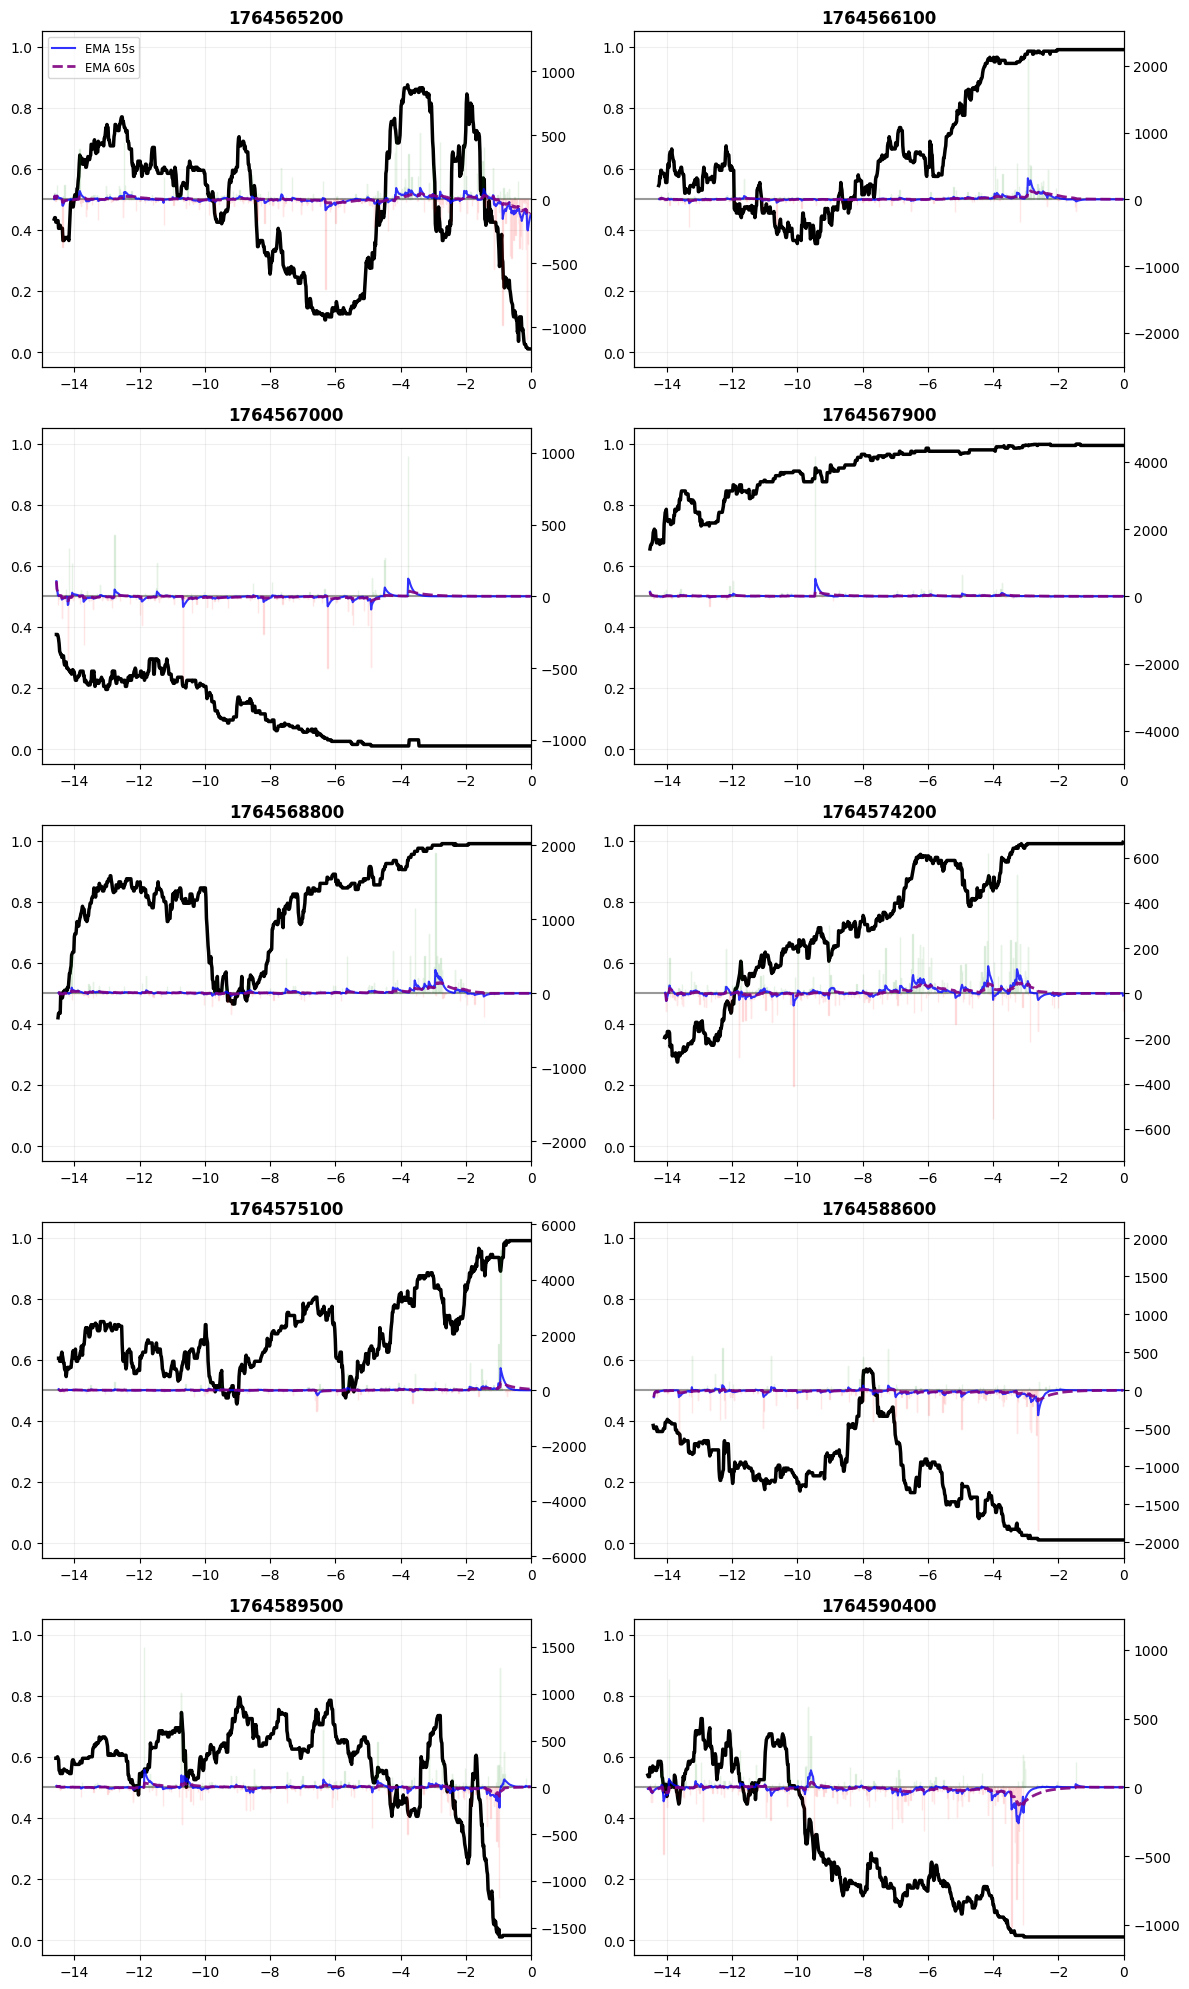

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 因子计算 (基于你的代码)
# ==========================================
plot_df = df.copy()

# 1.1 计算原始净流入
bull_notional = plot_df.get('Up_BUY_notional', 0) + plot_df.get('Down_SELL_notional', 0)
bear_notional = plot_df.get('Up_SELL_notional', 0) + plot_df.get('Down_BUY_notional', 0)
plot_df['Net_Nominal_Flow'] = bull_notional - bear_notional

# 1.2 计算平滑均线 (SMA & EMA)
plot_df['Net_Flow_sma_5s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.rolling(5, min_periods=1).mean())
plot_df['Net_Flow_sma_15s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.rolling(15, min_periods=1).mean())
plot_df['Net_Flow_sma_60s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.rolling(60, min_periods=1).mean())

plot_df['Net_Flow_ema_15s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=15, min_periods=1).mean())
plot_df['Net_Flow_ema_60s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=60, min_periods=1).mean())

# 1.3 辅助列准备
plot_df['minutes_to_expiry'] = - (plot_df['time_to_expiry'] / 60)
plot_df['Up_mid_price'] = plot_df[['Up_book_bid1_price', 'Up_book_ask1_price']].mean(axis=1).clip(0, 1)

# ==========================================
# 2. 完美对齐的网格绘图函数
# ==========================================
def plot_flow_vs_price_grid(data, slug_family='btc-updown-15m', n_cols=5, n_rows=10):
    family_data = data[data['slug'].str.contains(slug_family, na=False)].copy()
    slugs = family_data['slug'].drop_duplicates().tolist()[:n_cols * n_rows]
    
    actual_plots = len(slugs)
    if actual_plots < n_cols * n_rows:
        print(f"提示：清洗后剩余的 {slug_family} 合约有 {actual_plots} 个。")
        n_rows = int(np.ceil(actual_plots / n_cols))
        
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    
    for i, slug in enumerate(slugs):
        ax1 = axes[i]
        contract = family_data[family_data['slug'] == slug].copy()
        
        if 'minutes_to_expiry' in contract.columns:
            contract = contract.loc[(contract['minutes_to_expiry'] >= -15) & (contract['minutes_to_expiry'] <= 0)]
        contract = contract.dropna(subset=['Up_mid_price'])
        
        if contract.empty: 
            ax1.set_visible(False)
            continue
            
        # ---------------------------------------------
        # 左轴：绘制 Mid-Price (黑色加粗)
        # ---------------------------------------------
        ax1.plot(contract['minutes_to_expiry'], contract['Up_mid_price'], color='black', linewidth=2.5, zorder=3)
        ax1.set_ylim(-0.05, 1.05)
        ax1.axhline(0.5, color='gray', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1) # 0.5 基准线
        
        # ---------------------------------------------
        # 右轴：绘制 资金流 (Net Flow)
        # ---------------------------------------------
        ax2 = ax1.twinx()
        
        # 1. 画原始脉冲 (浅色面积/柱状图打底，只看轮廓)
        ax2.fill_between(contract['minutes_to_expiry'], 0, contract['Net_Nominal_Flow'], 
                         where=(contract['Net_Nominal_Flow'] > 0), color='green', alpha=0.1, step='mid')
        ax2.fill_between(contract['minutes_to_expiry'], 0, contract['Net_Nominal_Flow'], 
                         where=(contract['Net_Nominal_Flow'] < 0), color='red', alpha=0.1, step='mid')
        
        # 2. 画 EMA 快线 (15s) - 捕捉敏锐突破
        ax2.plot(contract['minutes_to_expiry'], contract['Net_Flow_ema_15s'], 
                 color='blue', linewidth=1.5, alpha=0.8, label='EMA 15s')
                 
        # 3. 画 EMA 慢线 (60s) - 捕捉大趋势
        ax2.plot(contract['minutes_to_expiry'], contract['Net_Flow_ema_60s'], 
                 color='purple', linewidth=2, linestyle='--', alpha=0.9, label='EMA 60s')
        
        # 强制右轴对称，使其 0 轴与左轴的 0.5 完美重合
        # 找出当前合约资金流的最大绝对值
        flow_cols = ['Net_Nominal_Flow', 'Net_Flow_ema_15s', 'Net_Flow_ema_60s']
        max_flow = contract[flow_cols].abs().max().max()
        if pd.isna(max_flow) or max_flow == 0: max_flow = 100 # 防止无交易报错
        
        y2_limit = max_flow * 1.2 # 留出 20% 上下边距
        ax2.set_ylim(-y2_limit, y2_limit)
        
        # ---------------------------------------------
        # 图表装饰
        # ---------------------------------------------
        ax1.set_title(f"{slug.split('-')[-1]}", fontweight='bold')
        ax1.set_xlim(-15, 0)
        ax1.grid(alpha=0.2)
        
        # 只在第一行第一列加图例，防止画面杂乱
        if i == 0:
            ax2.legend(loc='upper left', fontsize='small')
        
    # 隐藏多余的空白子图
    for j in range(actual_plots, len(axes)):
        axes[j].set_visible(False)
        
    fig.tight_layout()
    plt.show()

# 运行绘图
plot_flow_vs_price_grid(plot_df, slug_family='btc-updown-15m', n_cols=2, n_rows=5)

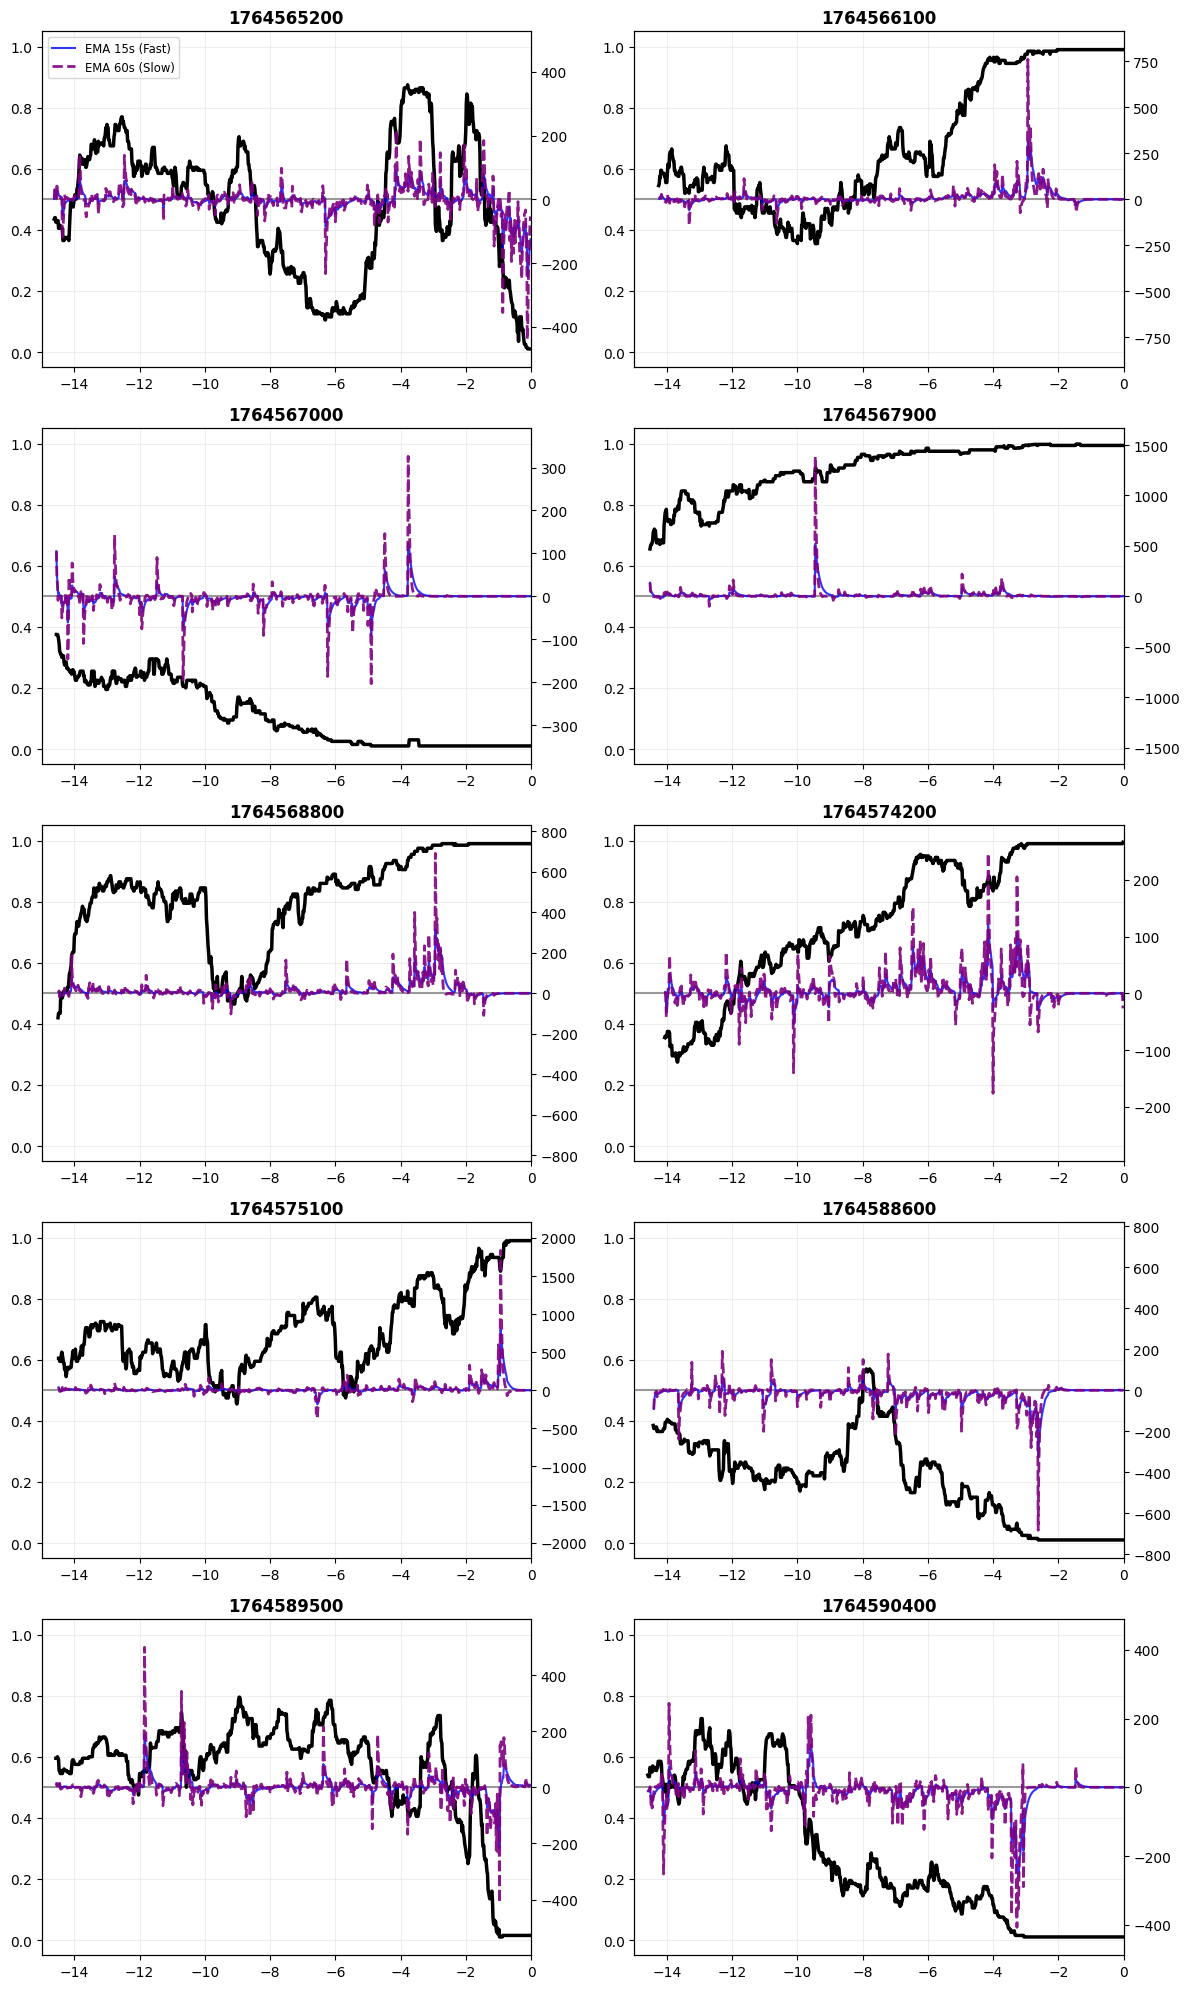

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 因子计算 
# ==========================================
plot_df = df.copy()

# 计算原始净流入
bull_notional = plot_df.get('Up_BUY_notional', 0) + plot_df.get('Down_SELL_notional', 0)
bear_notional = plot_df.get('Up_SELL_notional', 0) + plot_df.get('Down_BUY_notional', 0)
plot_df['Net_Nominal_Flow'] = bull_notional - bear_notional

# 仅保留 EMA 计算
plot_df['Net_Flow_ema_15s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=15, min_periods=1).mean())
plot_df['Net_Flow_ema_60s'] = plot_df.groupby('slug')['Net_Nominal_Flow'].transform(lambda x: x.ewm(span=5, min_periods=1).mean())

# 辅助列准备
plot_df['minutes_to_expiry'] = - (plot_df['time_to_expiry'] / 60)
plot_df['Up_mid_price'] = plot_df[['Up_book_bid1_price', 'Up_book_ask1_price']].mean(axis=1).clip(0, 1)

# ==========================================
# 2. 剔除噪音、只看 EMA 的清爽版绘图函数
# ==========================================
def plot_flow_vs_price_grid(data, slug_family='btc-updown-15m', n_cols=2, n_rows=5):
    family_data = data[data['slug'].str.contains(slug_family, na=False)].copy()
    slugs = family_data['slug'].drop_duplicates().tolist()[:n_cols * n_rows]
    
    actual_plots = len(slugs)
    if actual_plots < n_cols * n_rows:
        print(f"提示：清洗后剩余的 {slug_family} 合约有 {actual_plots} 个。")
        n_rows = int(np.ceil(actual_plots / n_cols))
        
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    
    for i, slug in enumerate(slugs):
        ax1 = axes[i]
        contract = family_data[family_data['slug'] == slug].copy()
        
        if 'minutes_to_expiry' in contract.columns:
            contract = contract.loc[(contract['minutes_to_expiry'] >= -15) & (contract['minutes_to_expiry'] <= 0)]
        contract = contract.dropna(subset=['Up_mid_price'])
        
        if contract.empty: 
            ax1.set_visible(False)
            continue
            
        # ---------------------------------------------
        # 左轴：绘制 Mid-Price
        # ---------------------------------------------
        ax1.plot(contract['minutes_to_expiry'], contract['Up_mid_price'], color='black', linewidth=2.5, zorder=3)
        ax1.set_ylim(-0.05, 1.05)
        ax1.axhline(0.5, color='gray', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)
        
        # ---------------------------------------------
        # 右轴：只绘制 EMA，抛弃原始脉冲
        # ---------------------------------------------
        ax2 = ax1.twinx()
        
        ax2.plot(contract['minutes_to_expiry'], contract['Net_Flow_ema_15s'], 
                 color='blue', linewidth=1.5, alpha=0.8, label='EMA 15s (Fast)')
                 
        ax2.plot(contract['minutes_to_expiry'], contract['Net_Flow_ema_60s'], 
                 color='purple', linewidth=2, linestyle='--', alpha=0.9, label='EMA 60s (Slow)')
        
        # ⭐ 核心修改：只用 EMA 来动态计算右轴的最大刻度！
        # 这样 Y 轴就会自适应平滑曲线，完美放大 EMA 的走势
        flow_cols = ['Net_Flow_ema_15s', 'Net_Flow_ema_60s']
        max_flow = contract[flow_cols].abs().max().max()
        if pd.isna(max_flow) or max_flow == 0: max_flow = 100 
        
        y2_limit = max_flow * 1.2 
        ax2.set_ylim(-y2_limit, y2_limit)
        
        # ---------------------------------------------
        # 图表装饰
        # ---------------------------------------------
        ax1.set_title(f"{slug.split('-')[-1]}", fontweight='bold')
        ax1.set_xlim(-15, 0)
        ax1.grid(alpha=0.2)
        
        if i == 0:
            ax2.legend(loc='upper left', fontsize='small')
        
    for j in range(actual_plots, len(axes)):
        axes[j].set_visible(False)
        
    fig.tight_layout()
    plt.show()

# 运行绘图
plot_flow_vs_price_grid(plot_df, slug_family='btc-updown-15m', n_cols=2, n_rows=5)

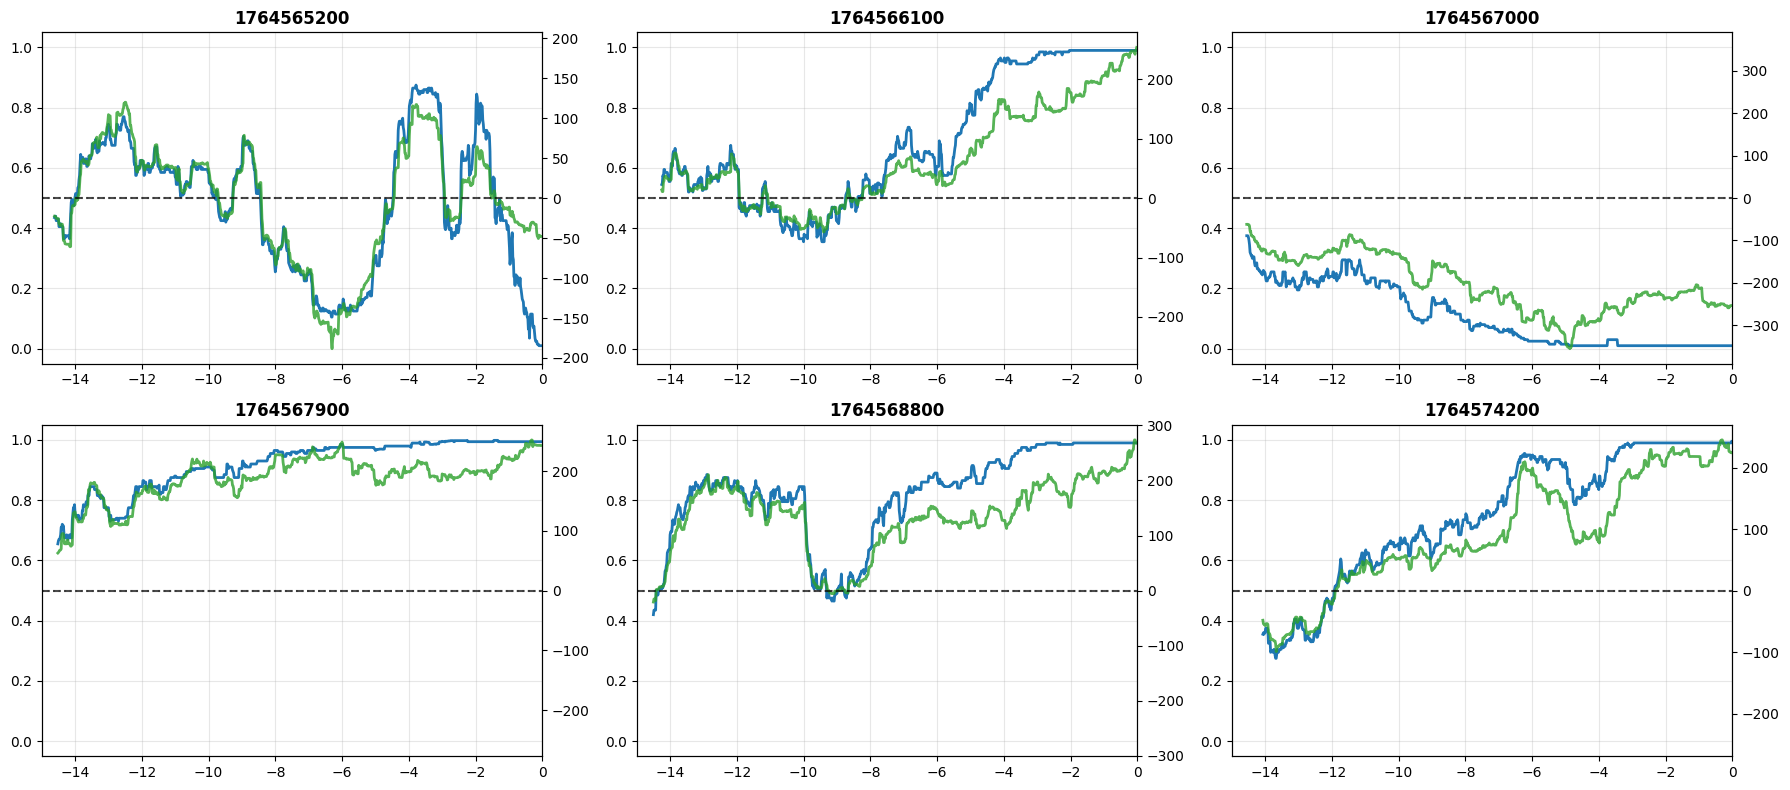

In [10]:
# Moneyness and Mid-price trend
import matplotlib.pyplot as plt
import numpy as np

plot_df = df.copy()

plot_df['minutes_to_expiry'] = - (plot_df['time_to_expiry'] / 60)

plot_df['Up_mid_price'] = plot_df[['Up_book_bid1_price', 'Up_book_ask1_price']].mean(axis=1).clip(0, 1)

plot_df['moneyness_abs'] = plot_df['moneyness']


def plot_aligned_contract_grid(data, slug_family='btc-updown-15m', n_cols=5, n_rows=10):
    family_data = data[data['slug'].str.contains(slug_family, na=False)].copy()
    
    slugs = family_data['slug'].drop_duplicates().tolist()[:n_cols * n_rows]
    
    actual_plots = len(slugs)
    if actual_plots < n_cols * n_rows:
        print(f"提示：清洗后剩余的 {slug_family} 合约只有 {actual_plots} 个。")
        n_rows = int(np.ceil(actual_plots / n_cols))
        
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    
    axes = np.array(axes).flatten()
    
    for i, slug in enumerate(slugs):
        ax1 = axes[i]
        contract = family_data[family_data['slug'] == slug].copy()
        
        if 'minutes_to_expiry' in contract.columns:
            contract = contract.loc[(contract['minutes_to_expiry'] >= -15) & (contract['minutes_to_expiry'] <= 0)]
        contract = contract.dropna(subset=['Up_mid_price', 'moneyness_abs'])
        
        if contract.empty: 
            ax1.set_visible(False)
            continue
            

        color1 = '#1f77b4'
        ax1.plot(contract['minutes_to_expiry'], contract['Up_mid_price'], color=color1, linewidth=2)
        ax1.set_ylim(-0.05, 1.05)
        ax1.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
        

        ax2 = ax1.twinx()
        color2 = '#2ca02c'
        ax2.plot(contract['minutes_to_expiry'], contract['moneyness_abs'], color=color2, linewidth=2, alpha=0.8)
        
        # Make Moneyness 0 strictly in parallel with 0.5 mid-price
        m_max = contract['moneyness_abs'].max()
        m_min = contract['moneyness_abs'].min()
        max_abs_bound = max(abs(m_max), abs(m_min))
        if max_abs_bound < 1: max_abs_bound = 1 
        
        y2_limit = max_abs_bound * 1.1 
        ax2.set_ylim(-y2_limit, y2_limit)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax1.set_title(f"{slug.split('-')[-1]}", fontweight='bold')
        ax1.set_xlim(-15, 0)
        ax1.grid(alpha=0.3)
        
    for j in range(actual_plots, len(axes)):
        axes[j].set_visible(False)
        
    fig.tight_layout()
    plt.show()

plot_aligned_contract_grid(plot_df, slug_family='btc-updown-15m', n_cols=3, n_rows=2)

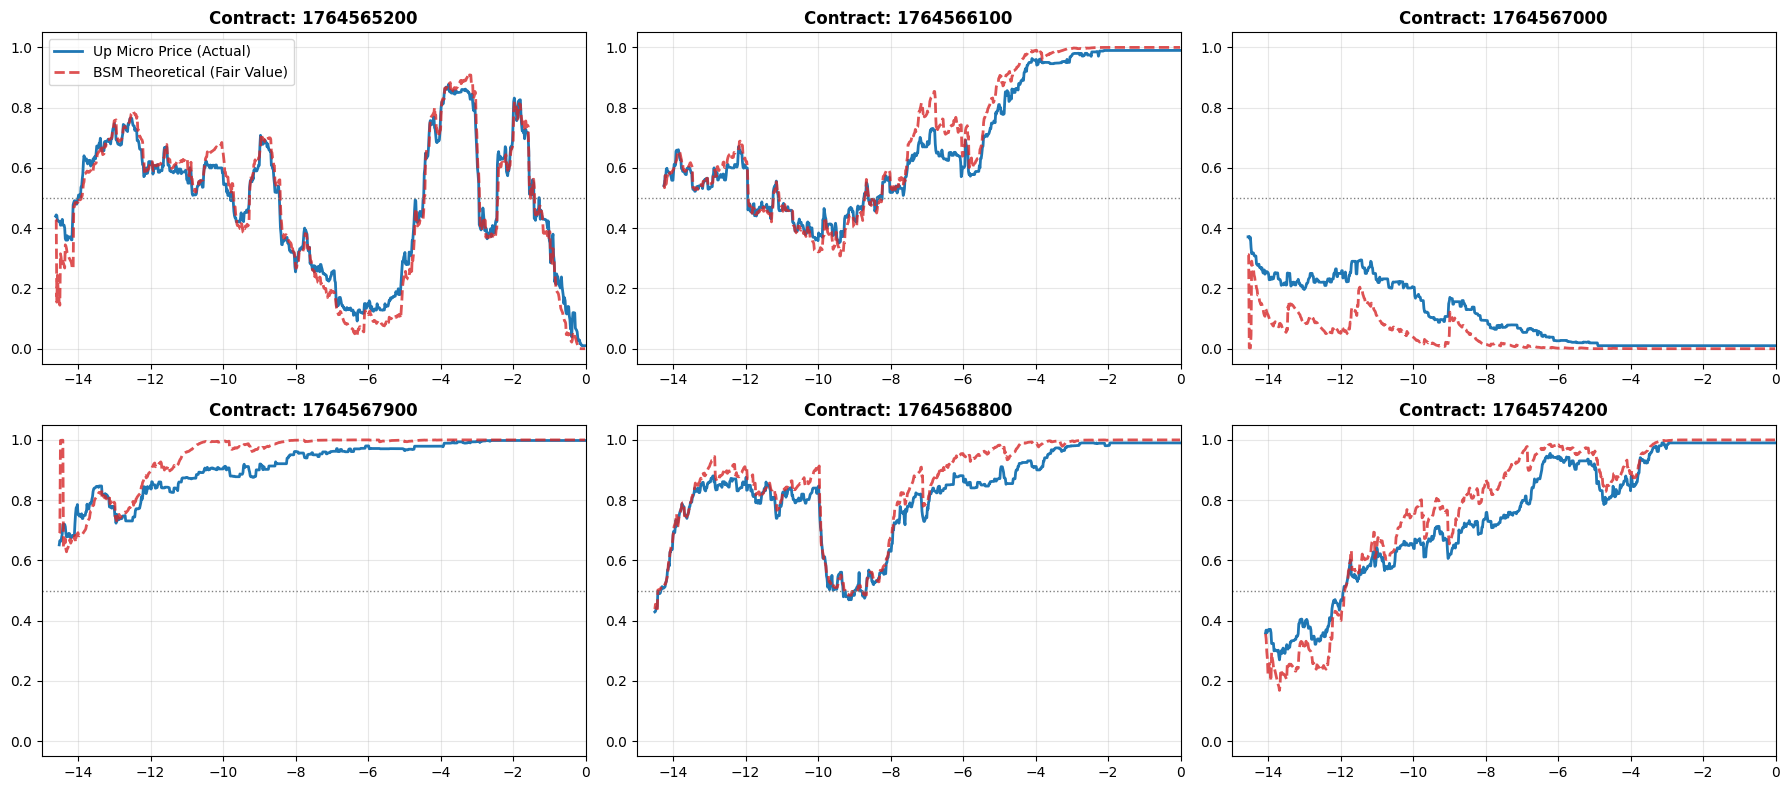

In [11]:
import matplotlib.pyplot as plt

def plot_price_vs_theoretical(data, slug_id, n_cols=3):
    # 如果传入的是特定的几个 slug
    if isinstance(slug_id, list):
        slugs = slug_id
    else:
        # 如果传入的是 dataframe，随便挑几个画
        slugs = data['slug'].drop_duplicates().tolist()[:6]
    
    n_rows = int(np.ceil(len(slugs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    
    for i, slug in enumerate(slugs):
        ax = axes[i]
        contract = data[data['slug'] == slug].copy()
        
        # 把时间轴换算成剩下的分钟数 (负数)
        minutes_to_expiry = - (contract['time_to_expiry'] / 60)
        
        # 画出真实的 Mid Price (蓝色实线)
        ax.plot(minutes_to_expiry, contract['Up_micro_price'], 
                label='Up Micro Price (Actual)', color='#1f77b4', linewidth=2)
        
        # 画出 BSM 理论价格 (红色虚线)
        ax.plot(minutes_to_expiry, contract['bsm_theoretical_price'], 
                label='BSM Theoretical (Fair Value)', color='#d62728', linestyle='--', linewidth=2, alpha=0.8)
        
        # 辅助线和样式
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(-15, 0)
        ax.set_title(f"Contract: {slug.split('-')[-1]}", fontweight='bold')
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc='upper left')

    # 隐藏多余的子图
    for j in range(len(slugs), len(axes)):
        axes[j].set_visible(False)
        
    fig.tight_layout()
    plt.show()

# 运行画图！
# 建议在你修正了 sigma 逻辑之后，把 df 传进去画图
plot_price_vs_theoretical(df, df['slug'].drop_duplicates().tolist()[:6])

In [ ]:
def dynamic_truncate_contracts(df):
    """
    预测市场专属：自适应动态切尾清洗函数
    """
    print(f"🔪 原始数据量: {len(df)} 行")
    
    # ==========================================
    # 1. 第一把刀：绝对时间防漏
    # ==========================================
    mask_time = df['time_to_expiry'] > 0
    df_clean = df[mask_time].copy()
    
    # ==========================================
    # 2. 第二把刀：价格极值剔除 (无交易价值区)
    # ==========================================
    # 只要价格进入极度确定区间，不管剩多少时间，统统不要
    # 因为 5s 预测在 0.99 变到 1.00 的过程中都是噪音
    upper_bound = 0.98
    lower_bound = 0.02
    mask_price = (df_clean['Up_Mid_Price'] <= upper_bound) & (df_clean['Up_Mid_Price'] >= lower_bound)
    df_clean = df_clean[mask_price]
    
    # ==========================================
    # 3. 第三把刀：流动性枯竭剔除 (识别假盘/死盘)
    # ==========================================
    # 假设我们定义最后 5 分钟 (300秒) 为高危期
    # 如果在这期间，买卖价差 (Up_spread) 大于 0.03 (3美分)，说明做市商已经跑路，认定为垃圾时间
    is_late_stage = df_clean['time_to_expiry'] < 300
    is_illiquid = df_clean['Up_spread'] > 0.03
    
    # 剔除那些【既是最后阶段】且【流动性又极差】的行
    mask_liquidity = ~(is_late_stage & is_illiquid)
    df_clean = df_clean[mask_liquidity]
    
    print(f"✨ 动态切尾完成！清洗后数据量: {len(df_clean)} 行")
    print(f"🗑️ 共切除垃圾时间数据: {len(df) - len(df_clean)} 行")
    
    return df_clean

# 在你做 Target Shift(-5) 和特征筛选之前，先跑这一步！
df = dynamic_truncate_contracts(df)

In [ ]:
df

,timestamp,Up_trade_open,Up_trade_high,Up_trade_low,Up_trade_close,Up_trade_volume,Up_book_bid1_price,Up_book_bid1_size,Up_book_bid2_price,Up_book_bid2_size,...,sigma_annualized,bsm_theoretical_price,bsm_delta,Up_OBI,Up_spread,Up_micro_price,Up_BUY_Urgency,Down_BUY_Urgency,Up_SELL_Urgency,Down_SELL_Urgency
0,2025-12-01 05:00:38+00:00,0.44,0.54,0.25,0.42,130801.53,0.40,20.00,0.39,5.00,...,0.131883,0.267781,0.005568,-0.325239,0.01,0.400510,2.500000e-02,4.600000e-03,-5.000000e-03,2.500000e-02
1,2025-12-01 05:00:39+00:00,0.37,0.51,0.22,0.28,68178.52,0.36,70.00,0.35,180.00,...,0.296856,0.344746,0.002769,-0.277695,0.01,0.365124,6.500000e-02,-1.946364e-02,-4.500000e-02,6.500000e-02
2,2025-12-01 05:00:40+00:00,0.42,0.48,0.22,0.23,34720.42,0.36,10.00,0.35,175.00,...,0.288631,0.341021,0.002838,-0.151914,0.01,0.360419,5.000000e-03,-1.946364e-02,-4.500000e-02,5.000000e-03
3,2025-12-01 05:00:41+00:00,0.32,0.48,0.22,0.41,38318.15,0.36,3.43,0.35,175.00,...,0.279046,0.332396,0.002908,0.026606,0.01,0.360201,5.000000e-03,5.000000e-03,-4.500000e-02,5.000000e-03
4,2025-12-01 05:00:42+00:00,0.38,0.50,0.22,0.34,26430.48,0.37,438.16,0.36,3.43,...,0.270866,0.318145,0.002945,-0.277872,0.01,0.374900,-5.000000e-03,1.500000e-02,-3.500000e-02,-4.418063e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580190,2025-12-15 03:15:02+00:00,0.03,0.03,0.01,0.02,2332.50,0.99,152544.11,0.98,50.00,...,0.133393,1.000000,0.000000,1.000000,0.00,0.990000,-1.110223e-16,-8.673617e-18,0.000000e+00,8.673617e-18
580191,2025-12-15 03:15:03+00:00,0.99,0.99,0.99,0.99,152470.11,0.99,152470.11,0.98,50.00,...,0.132287,1.000000,0.000000,1.000000,0.00,0.990000,-1.110223e-16,-8.673617e-18,1.110223e-16,8.673617e-18
580192,2025-12-15 03:15:04+00:00,0.99,0.99,0.01,0.01,154052.46,0.99,152468.73,0.98,50.00,...,0.131190,1.000000,0.000000,1.000000,0.00,0.990000,-1.110223e-16,-8.673617e-18,0.000000e+00,8.673617e-18
580193,2025-12-15 03:15:05+00:00,0.99,0.99,0.95,0.96,460841.24,0.99,152468.73,0.98,50.00,...,0.130102,1.000000,0.000000,1.000000,0.00,0.990000,NaN,NaN,NaN,NaN
